
# Multiobjective Optimization with PyMoo: an illustrative tutorial

This notebook moves from intuition to practice. You will:

- visualize Pareto dominance on a simple grid,
- solve a standard benchmark problem with **NSGA-II**,
- define a **custom constrained** multiobjective problem,
- inspect convergence with **hypervolume**, and
- pick a **single compromise design** from a Pareto set.

PyMoo is an open-source Python framework for single- and multi-objective optimization, with algorithms, indicators, visualization, and basic decision-making support. This notebook is written against the current PyMoo **0.6.1.6** documentation and paper:

- [PyPI project page](https://pypi.org/project/pymoo/)
- [Getting Started guide](https://pymoo.org/getting_started/index.html)
- Blank and Deb, *pymoo: Multi-Objective Optimization in Python*, IEEE Access (2020), [doi:10.1109/ACCESS.2020.2990567](https://doi.org/10.1109/ACCESS.2020.2990567)



## 0. Setup

PyMoo's basic workflow is:

1. define or load a `Problem`,
2. choose an `Algorithm`,
3. choose a `Termination`, and
4. call `minimize(...)`.

The relevant interface docs are:

- [`minimize`](https://pymoo.org/interface/minimize.html)
- [`Problem` / `ElementwiseProblem`](https://pymoo.org/interface/problem.html)
- [`Termination`](https://pymoo.org/interface/termination.html)

For custom problems, objectives are written to `out["F"]`, and inequality constraints are written to `out["G"]` using the convention **`G <= 0` means feasible**.


In [2]:

# If you need the package locally, uncomment the next line.
%pip install -q "pymoo>=0.6.1.6" #numpy matplotlib pandas

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.core.problem import ElementwiseProblem
from pymoo.decomposition.asf import ASF
from pymoo.indicators.hv import HV
from pymoo.indicators.igd import IGD
from pymoo.mcdm.pseudo_weights import PseudoWeights
from pymoo.optimize import minimize
from pymoo.problems import get_problem
from pymoo.util.nds.non_dominated_sorting import NonDominatedSorting
import pymoo

plt.rcParams["figure.dpi"] = 130
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
np.random.seed(42)

print(f"PyMoo version: {pymoo.__version__}")


Note: you may need to restart the kernel to use updated packages.
PyMoo version: 0.6.1.6



## 1. Pareto dominance in one picture

In multiobjective optimization, we usually cannot collapse everything into a single “best” point without making a value judgment.

Instead, we look for **Pareto-optimal** points:

- design **A dominates B** if A is **no worse in every objective** and **strictly better in at least one**,
- the **Pareto set** lives in the decision space,
- the **Pareto front** is its image in objective space.

Below, we create a tiny toy problem by evaluating a dense grid of designs. This is **not** how you would solve a real problem; it is only meant to build intuition.


Toy grid size:        6,400 candidate designs
Non-dominated points: 583


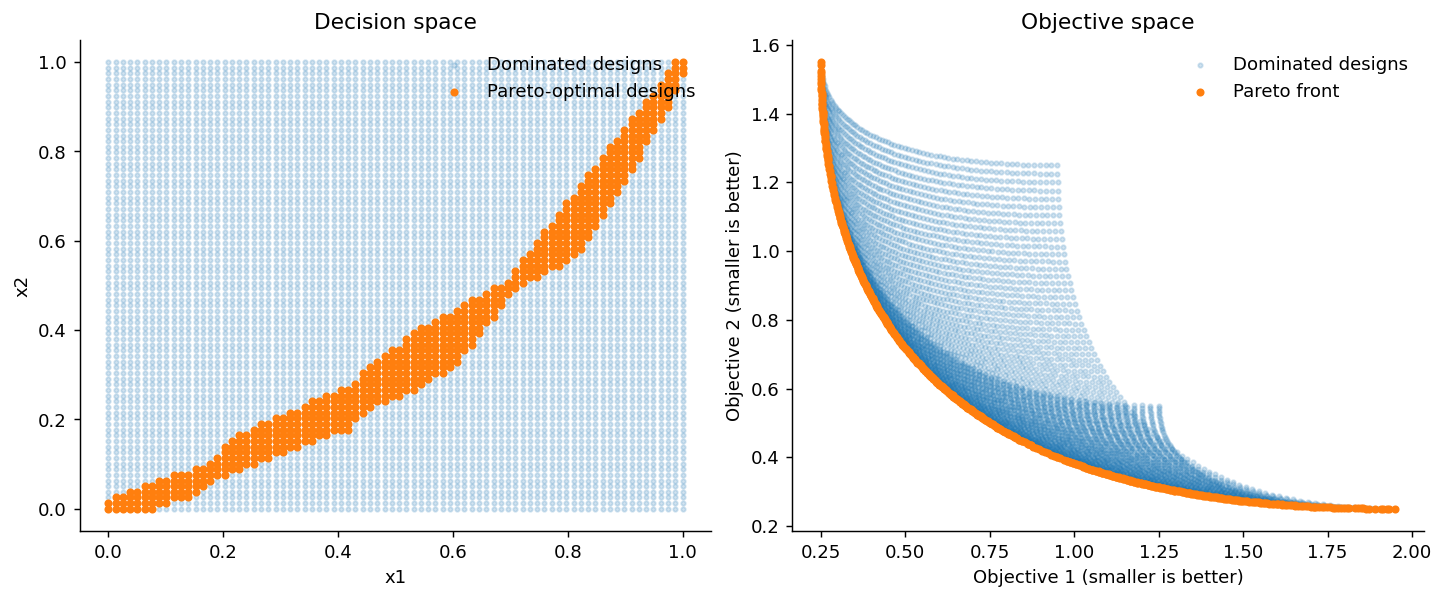

In [3]:

# Toy design space: two controllable design variables in [0, 1].
# Two conflicting objectives, both to be minimized.

grid = np.linspace(0.0, 1.0, 80)
X0, X1 = np.meshgrid(grid, grid)
X_toy = np.column_stack([X0.ravel(), X1.ravel()])

F_toy = np.column_stack([
    0.25 + X_toy[:, 0]**2 + 0.70 * X_toy[:, 1]**2,
    0.25 + (1.0 - X_toy[:, 0])**2 + 0.30 * (1.0 - X_toy[:, 1])**2,
])

nd_idx = NonDominatedSorting().do(F_toy, only_non_dominated_front=True)
is_nd = np.zeros(len(X_toy), dtype=bool)
is_nd[nd_idx] = True

print(f"Toy grid size:        {len(X_toy):,} candidate designs")
print(f"Non-dominated points: {is_nd.sum():,}")

fig, ax = plt.subplots(1, 2, figsize=(11, 4.5), constrained_layout=True)

ax[0].scatter(X_toy[~is_nd, 0], X_toy[~is_nd, 1], s=6, alpha=0.20, label="Dominated designs")
ax[0].scatter(X_toy[is_nd, 0], X_toy[is_nd, 1], s=12, label="Pareto-optimal designs")
ax[0].set_xlabel("x1")
ax[0].set_ylabel("x2")
ax[0].set_title("Decision space")
ax[0].legend(frameon=False, loc="best")

ax[1].scatter(F_toy[~is_nd, 0], F_toy[~is_nd, 1], s=6, alpha=0.20, label="Dominated designs")
ax[1].scatter(F_toy[is_nd, 0], F_toy[is_nd, 1], s=12, label="Pareto front")
ax[1].set_xlabel("Objective 1 (smaller is better)")
ax[1].set_ylabel("Objective 2 (smaller is better)")
ax[1].set_title("Objective space")
ax[1].legend(frameon=False, loc="best")

plt.show()



The optimizer's job is to discover that trade-off frontier **without evaluating every possible design**. That is where PyMoo's algorithms come in.



## 2. Quick start on a standard benchmark: ZDT1

We start with **ZDT1**, a classic two-objective benchmark problem that is built into PyMoo. It has a known Pareto front, which makes it a good sanity check.

We will use **NSGA-II**, which PyMoo documents as a non-dominated sorting genetic algorithm with crowding-distance-based diversity preservation:

- [NSGA-II documentation](https://pymoo.org/algorithms/moo/nsga2.html)
- [Built-in problems](https://pymoo.org/problems/index.html)

PyMoo has default multiobjective termination rules, but here we use an explicit generation cap so the notebook stays predictable and quick to rerun.


In [5]:

problem = get_problem("zdt1")
algorithm = NSGA2(pop_size=100)

res_zdt1 = minimize(
    problem,
    algorithm,
    ("n_gen", 180),
    seed=7,
    save_history=True,
    verbose=False,
)

pf = problem.pareto_front()

print(f"Decision-variable array shape: {res_zdt1.X.shape}")
print(f"Objective-value array shape:   {res_zdt1.F.shape}")


Decision-variable array shape: (100, 30)
Objective-value array shape:   (100, 2)


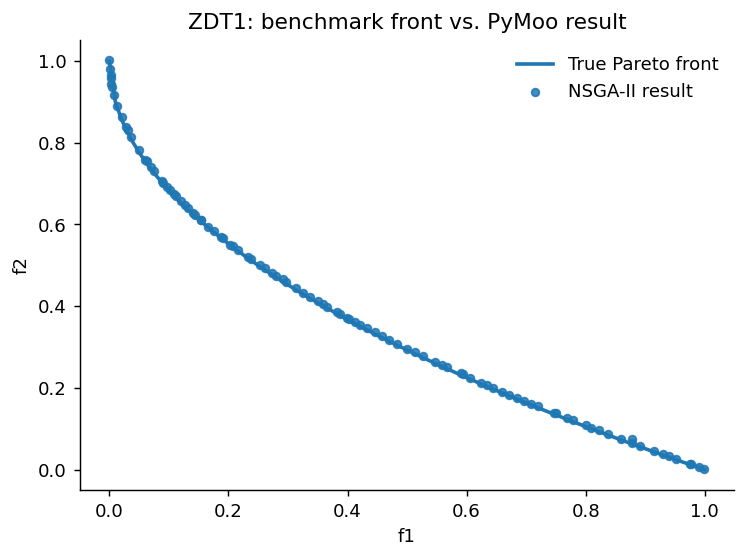

,metric,value
0,Hypervolume (higher is better),0.8677
1,IGD (lower is better),0.0054


In [6]:

# Compare the approximate front returned by NSGA-II with the known ZDT1 front.

hv_value = HV(ref_point=np.array([1.1, 1.1]))(res_zdt1.F)
igd_value = IGD(pf)(res_zdt1.F)

fig, ax = plt.subplots(figsize=(6.5, 4.5))
ax.plot(pf[:, 0], pf[:, 1], linewidth=2, label="True Pareto front")
ax.scatter(res_zdt1.F[:, 0], res_zdt1.F[:, 1], s=18, alpha=0.85, label="NSGA-II result")
ax.set_xlabel("f1")
ax.set_ylabel("f2")
ax.set_title("ZDT1: benchmark front vs. PyMoo result")
ax.legend(frameon=False)
plt.show()

metric_table = pd.DataFrame(
    {
        "metric": [
            "Hypervolume (higher is better)",
            "IGD (lower is better)",
        ],
        "value": [hv_value, igd_value],
    }
)

display(metric_table.round(4))



### Convergence diagnostics with `save_history=True`

PyMoo can save the state of the algorithm at every generation via `save_history=True` in `minimize(...)`. That makes it easy to inspect how a run evolved afterward.

A useful quality indicator is **hypervolume**:

- it needs a **reference point**,
- it measures the dominated area/volume,
- **larger is better**.

See PyMoo's docs on [analysis of convergence](https://pymoo.org/getting_started/part_4.html) and [performance indicators](https://pymoo.org/misc/indicators.html).


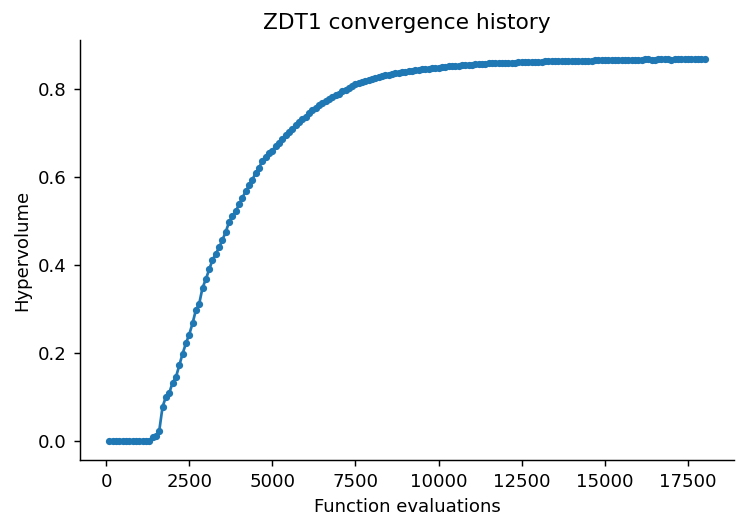

Final hypervolume: 0.8677


In [7]:

# Hypervolume history over the run.
# For ZDT1, a reference point such as [1.1, 1.1] is safely outside the Pareto front.

hv_metric = HV(ref_point=np.array([1.1, 1.1]))
hv_history = []
n_evals = []

for algo in res_zdt1.history:
    hv_history.append(hv_metric(algo.opt.get("F")))
    n_evals.append(algo.evaluator.n_eval)

fig, ax = plt.subplots(figsize=(6.5, 4.2))
ax.plot(n_evals, hv_history, marker="o", markersize=3)
ax.set_xlabel("Function evaluations")
ax.set_ylabel("Hypervolume")
ax.set_title("ZDT1 convergence history")
plt.show()

print(f"Final hypervolume: {hv_history[-1]:.4f}")



## 3. Defining your own problem

Benchmarks are useful, but the important skill is translating a real design problem into PyMoo's API.

We will create a stylized **portable battery-pack design** problem with two decision variables:

- `x[0]`: number of battery modules,
- `x[1]`: insulation thickness.

We want to:

$
\min f_1(x) = \text{mass}(x), \qquad \min f_2(x) = -\text{runtime}(x)
$

subject to the budget constraint

$
g_1(x) = \text{cost}(x) - 360 \le 0.
$

Two implementation details matter:

1. **PyMoo minimizes all objectives**, so maximizing runtime becomes minimizing `-runtime`.
2. Constraints go into `out["G"]` and are feasible when `<= 0`.

PyMoo's `Problem` / `ElementwiseProblem` documentation is here:

- [Problem definition docs](https://pymoo.org/interface/problem.html)


In [8]:

class PortableBatteryProblem(ElementwiseProblem):
    """Minimize pack mass and maximize runtime under a cost budget."""

    def __init__(self):
        super().__init__(
            n_var=2,
            n_obj=2,
            n_ieq_constr=1,
            xl=np.array([0.0, 0.0]),
            xu=np.array([4.0, 4.0]),
        )

    def _evaluate(self, x, out, *args, **kwargs):
        battery_modules, insulation = x

        runtime = (
            4.0
            + 2.2 * battery_modules
            + 1.4 * insulation
            - 0.25 * battery_modules * insulation
            - 0.18 * (insulation - 2.0) ** 2
        )
        mass = 1.2 + 1.3 * battery_modules + 0.9 * insulation + 0.08 * battery_modules**2
        cost = (
            180.0
            + 45.0 * battery_modules
            + 28.0 * insulation
            + 10.0 * (battery_modules - 2.2) ** 2
            + 6.0 * (insulation - 1.5) ** 2
        )

        out["F"] = [mass, -runtime]      # minimize mass, maximize runtime
        out["G"] = [cost - 360.0]        # feasible if <= 0


def battery_metrics(X):
    """Return mass, runtime, and cost for one or more design vectors."""
    X = np.atleast_2d(X)
    battery_modules = X[:, 0]
    insulation = X[:, 1]

    runtime = (
        4.0
        + 2.2 * battery_modules
        + 1.4 * insulation
        - 0.25 * battery_modules * insulation
        - 0.18 * (insulation - 2.0) ** 2
    )
    mass = 1.2 + 1.3 * battery_modules + 0.9 * insulation + 0.08 * battery_modules**2
    cost = (
        180.0
        + 45.0 * battery_modules
        + 28.0 * insulation
        + 10.0 * (battery_modules - 2.2) ** 2
        + 6.0 * (insulation - 1.5) ** 2
    )

    return pd.DataFrame(
        {
            "battery_modules": battery_modules,
            "insulation": insulation,
            "runtime_h": runtime,
            "mass_kg": mass,
            "cost_usd": cost,
        }
    )


In [9]:

custom_problem = PortableBatteryProblem()

res_custom = minimize(
    custom_problem,
    NSGA2(pop_size=80),
    ("n_gen", 150),
    seed=11,
    verbose=False,
)

custom_metrics = battery_metrics(res_custom.X)

summary = pd.DataFrame(
    {
        "quantity": ["Returned non-dominated solutions", "Mass range (kg)", "Runtime range (h)", "Cost range ($)"],
        "value": [
            len(res_custom.F),
            f"{custom_metrics['mass_kg'].min():.3f} to {custom_metrics['mass_kg'].max():.3f}",
            f"{custom_metrics['runtime_h'].min():.3f} to {custom_metrics['runtime_h'].max():.3f}",
            f"{custom_metrics['cost_usd'].min():.3f} to {custom_metrics['cost_usd'].max():.3f}",
        ],
    }
)

display(summary)


,quantity,value
0,Returned non-dominated solutions,80
1,Mass range (kg),1.200 to 7.069
2,Runtime range (h),3.280 to 11.426
3,Cost range ($),241.900 to 359.955


Dense-grid feasible designs: 8,351
Dense-grid Pareto designs:   1,169


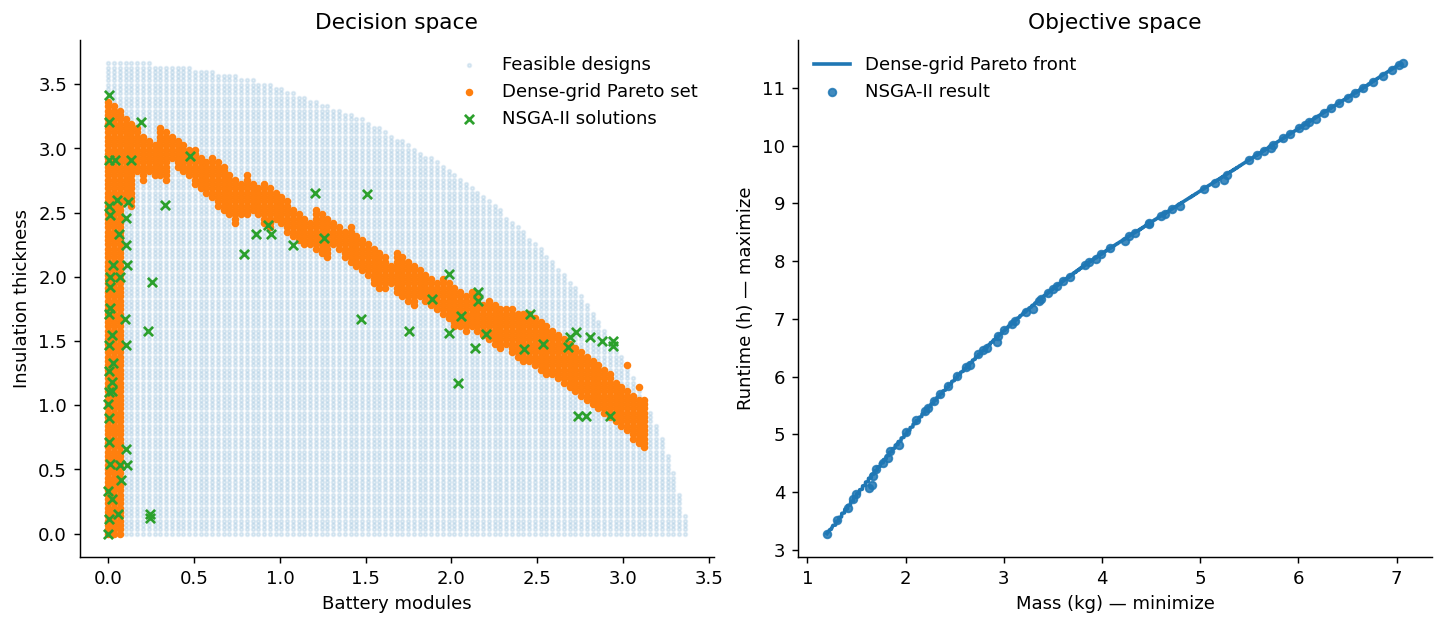

In [10]:

# Because this example has only two design variables, we can also build a dense-grid
# approximation to the feasible Pareto set and compare NSGA-II against it.

fine = np.linspace(0.0, 4.0, 120)
G0, G1 = np.meshgrid(fine, fine)
X_dense = np.column_stack([G0.ravel(), G1.ravel()])
metrics_dense = battery_metrics(X_dense)

feasible = metrics_dense["cost_usd"].to_numpy() <= 360.0
F_dense = np.column_stack([
    metrics_dense.loc[feasible, "mass_kg"].to_numpy(),
    -metrics_dense.loc[feasible, "runtime_h"].to_numpy(),
])
X_feasible = X_dense[feasible]

nd_dense = NonDominatedSorting().do(F_dense, only_non_dominated_front=True)
F_dense_front = F_dense[nd_dense]
X_dense_front = X_feasible[nd_dense]

order = np.argsort(F_dense_front[:, 0])

print(f"Dense-grid feasible designs: {len(X_feasible):,}")
print(f"Dense-grid Pareto designs:   {len(F_dense_front):,}")

fig, ax = plt.subplots(1, 2, figsize=(11, 4.7), constrained_layout=True)

ax[0].scatter(X_feasible[:, 0], X_feasible[:, 1], s=4, alpha=0.12, label="Feasible designs")
ax[0].scatter(X_dense_front[:, 0], X_dense_front[:, 1], s=10, label="Dense-grid Pareto set")
ax[0].scatter(res_custom.X[:, 0], res_custom.X[:, 1], s=26, marker="x", label="NSGA-II solutions")
ax[0].set_xlabel("Battery modules")
ax[0].set_ylabel("Insulation thickness")
ax[0].set_title("Decision space")
ax[0].legend(frameon=False, loc="best")

ax[1].plot(F_dense_front[order, 0], -F_dense_front[order, 1], linewidth=2, label="Dense-grid Pareto front")
ax[1].scatter(res_custom.F[:, 0], -res_custom.F[:, 1], s=18, alpha=0.85, label="NSGA-II result")
ax[1].set_xlabel("Mass (kg) — minimize")
ax[1].set_ylabel("Runtime (h) — maximize")
ax[1].set_title("Objective space")
ax[1].legend(frameon=False, loc="best")

plt.show()



The dense-grid approximation is only feasible here because the toy problem has **two** decision variables. In realistic engineering models, brute force usually becomes impossible very quickly, which is exactly why evolutionary multiobjective methods are useful.



## 4. Choosing one compromise solution

Multiobjective optimization usually returns a **set** of valid trade-offs. A human still has to decide which trade-off is acceptable.

PyMoo includes a few basic **multi-criteria decision making (MCDM)** tools, including:

- **ASF** (achievement scalarization function),
- **Pseudo-weights**.

Before doing that, it is important to **normalize objectives**; otherwise one objective can dominate the distance calculation merely because it has a larger numerical scale. PyMoo's getting-started guide explicitly emphasizes this point:

- [Decision-making guide / normalization](https://pymoo.org/getting_started/part_3.html)

Below, we give runtime a bit more importance than mass using weights `[0.4, 0.6]`.


,method,battery_modules,insulation,mass_kg,runtime_h,cost_usd
0,ASF,0.191,3.205,4.335,8.493,336.136
1,PseudoWeights,0.477,2.939,4.483,8.655,325.864


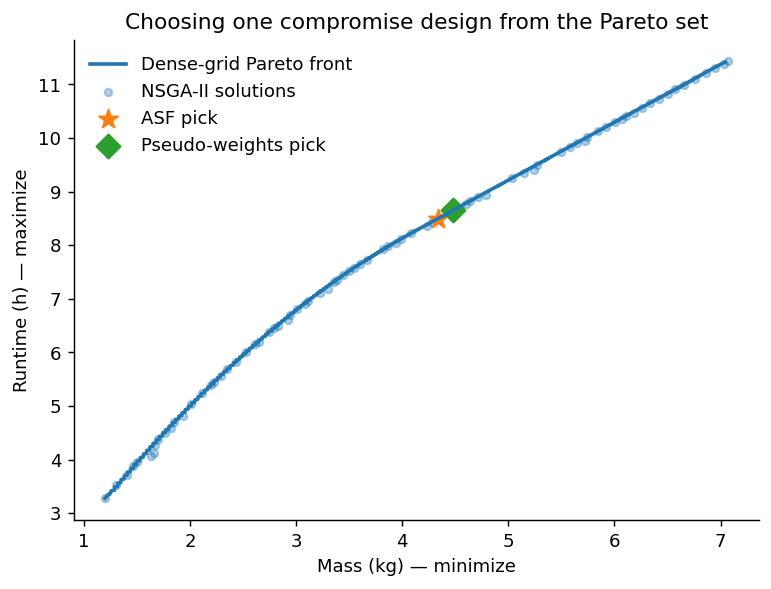

In [11]:

F = res_custom.F
ideal = F.min(axis=0)
nadir = F.max(axis=0)
nF = (F - ideal) / (nadir - ideal)

weights = np.array([0.4, 0.6])

# PyMoo's ASF uses a divide-by-weights form, so we pass 1 / weights.
i_asf = ASF().do(nF, 1 / weights).argmin()
i_pw = PseudoWeights(weights).do(nF)

choice_df = pd.concat(
    [
        custom_metrics.iloc[[i_asf]].assign(method="ASF"),
        custom_metrics.iloc[[i_pw]].assign(method="PseudoWeights"),
    ]
)[["method", "battery_modules", "insulation", "mass_kg", "runtime_h", "cost_usd"]].reset_index(drop=True)

display(choice_df.round(3))

fig, ax = plt.subplots(figsize=(6.8, 4.8))
ax.plot(F_dense_front[order, 0], -F_dense_front[order, 1], linewidth=2, label="Dense-grid Pareto front")
ax.scatter(res_custom.F[:, 0], -res_custom.F[:, 1], s=18, alpha=0.35, label="NSGA-II solutions")
ax.scatter(res_custom.F[i_asf, 0], -res_custom.F[i_asf, 1], s=120, marker="*", label="ASF pick")
ax.scatter(res_custom.F[i_pw, 0], -res_custom.F[i_pw, 1], s=90, marker="D", label="Pseudo-weights pick")
ax.set_xlabel("Mass (kg) — minimize")
ax.set_ylabel("Runtime (h) — maximize")
ax.set_title("Choosing one compromise design from the Pareto set")
ax.legend(frameon=False, loc="best")
plt.show()



## References

- PyMoo project page: <https://pypi.org/project/pymoo/>
- PyMoo getting started: <https://pymoo.org/getting_started/index.html>
- `minimize` interface: <https://pymoo.org/interface/minimize.html>
- Problem definition: <https://pymoo.org/interface/problem.html>
- Termination criteria: <https://pymoo.org/interface/termination.html>
- NSGA-II: <https://pymoo.org/algorithms/moo/nsga2.html>
- Performance indicators: <https://pymoo.org/misc/indicators.html>
- MCDM / decision making: <https://pymoo.org/getting_started/part_3.html>
- Blank, J. and Deb, K. (2020). *pymoo: Multi-Objective Optimization in Python*. IEEE Access, 8, 89497–89509. <https://doi.org/10.1109/ACCESS.2020.2990567>
